<div style="background:linear-gradient(135deg,#42275a 0%,#734b6d 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🪜&nbsp; Progressive (Multi-Scale) Training</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">PINNs train more reliably when you start easy and ramp up difficulty — a curriculum. We train coarse first, then refine with far more collocation points, and watch the loss take a second dive.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">advanced</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">curriculum · refinement</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~2 min · CPU</span></span></div>

A randomly-initialised network thrown straight at a sharp-front PDE often stalls. **Progressive
training** sidesteps this: a cheap *coarse* phase finds a good basin of attraction, then a *fine*
phase with many more collocation points sharpens the solution.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#idea" style="color:#1a73e8;text-decoration:none;">1 · The Curriculum Idea</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#coarse" style="color:#1a73e8;text-decoration:none;">3 · Phase 1 — Coarse</a></li>
  <li style="margin:3px 0;"><a href="#fine" style="color:#1a73e8;text-decoration:none;">4 · Phase 2 — Fine</a></li>
  <li style="margin:3px 0;"><a href="#compare" style="color:#1a73e8;text-decoration:none;">5 · The Two-Stage Loss Curve</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="idea"></a>

## 1 · The Curriculum Idea

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> Coarse sampling = a smooth, forgiving loss landscape that's easy to descend. Once near a good solution, dense sampling refines the details the coarse phase couldn't resolve.
</div>

<a id="setup"></a>

## 2 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
pinn = ContinuousPINN(MLP(2, 5, 40, 1), DEVICE, burgers_residual, cfg)

<a id="coarse"></a>

## 3 · Phase 1 — Coarse

Few collocation points, just enough to learn the broad structure.

In [3]:
hist_coarse = pinn.train(
    TrainConfig(n_u0=100, n_bc=60, n_f=500, adam_steps=1_200,
                lbfgs_max_iter=0, seed=SEED, track_losses=True),
    weights=(10.0, 1.0, 1.0))
print(f"After coarse phase: loss = {hist_coarse['total'][-1]:.3e}")

After coarse phase: loss = 1.382e-01


<a id="fine"></a>

## 4 · Phase 2 — Fine

We continue from the coarse weights (the same `pinn` object) with 4× the collocation points.

In [4]:
hist_fine = pinn.train(
    TrainConfig(n_u0=200, n_bc=120, n_f=2_000, adam_steps=1_200,
                lbfgs_max_iter=30, seed=SEED, track_losses=True),
    weights=(10.0, 1.0, 1.0))
print(f"After fine phase:   loss = {hist_fine['total'][-1]:.3e}")

After fine phase:   loss = 2.189e-02


<a id="compare"></a>

## 5 · The Two-Stage Loss Curve

Concatenating the two histories shows the characteristic second drop when refinement kicks in.

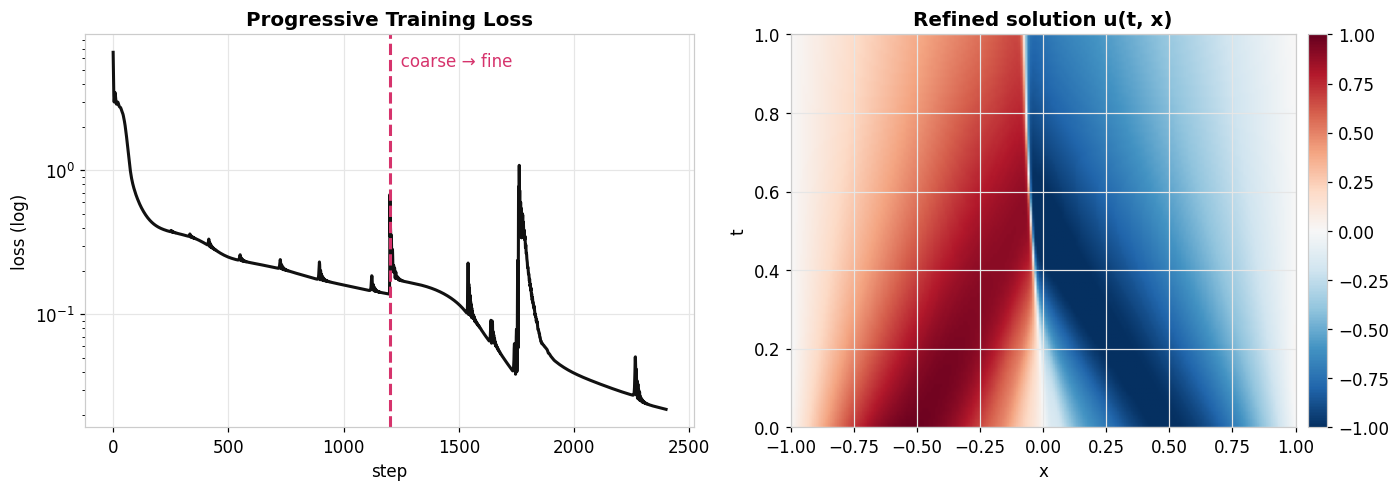

In [5]:
total = hist_coarse["total"] + hist_fine["total"]
boundary = len(hist_coarse["total"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(total, color="#111", lw=2)
a1.axvline(boundary, color=ACCENT2, ls="--", lw=2)
a1.text(boundary, max(total), "  coarse → fine", color=ACCENT2, va="top")
a1.set_yscale("log"); a1.set(title="Progressive Training Loss", xlabel="step", ylabel="loss (log)")

nt, nx = 100, 220
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
U = pinn.predict(TT, XX)
im = a2.imshow(U, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
a2.set(title="Refined solution u(t, x)", xlabel="x", ylabel="t"); fig.colorbar(im, ax=a2, pad=0.02)
plt.tight_layout(); plt.show()

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> The dashed line marks the phase switch. The fine phase resolves the steep front near x = 0 that the coarse phase could only approximate.
</div>

<a id="takeaways"></a>

## 6 · Takeaways

- **Progressive training** (coarse → fine) is a cheap, robust way to improve PINN convergence on
  stiff problems.
- Reusing the same model across phases means the fine stage *starts* from a good solution.
- The library also provides dedicated multi-scale architectures and trainers
  (`MultiScalePINN`, `MultiScaleTrainer`) — benchmarked in
  [`benchmarks/04_multiscale_comparison`](../benchmarks/04_multiscale_comparison.ipynb).

### 📚 References

1. Krishnapriyan, A. et al. (2021). *Characterizing possible failure modes in physics-informed neural networks*. NeurIPS.
2. Wang, S., Teng, Y., & Perdikaris, P. (2021). *Understanding and mitigating gradient pathologies in PINNs*. SIAM J. Sci. Comput., 43(5), A3055–A3081.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>